# Mission Earth- Forest-Fire Risk Prediction
### CIA-3
#### BY: ADITI AHUJA

**Problem statement.** Forest departments in under-resourced regions cannot patrol every area of a
park continuously. This notebook predicts, from meteorological and Fire-Weather-Index readings alone,
whether a reported ignition will **escalate into a damaging fire** — so patrol resources can be
prioritised before a fire spreads.

**Beneficiaries.** Forest departments and fire-watch teams with limited patrol resources.

**Dataset.** UCI Machine Learning Repository — Forest Fires Data Set (ID 162), 517 records.
Cortez, P. & Morais, A. (2007). *A Data Mining Approach to Predict Forest Fires using Meteorological
Data.* Proceedings of the 13th EPIA 2007. https://archive.ics.uci.edu/dataset/162/forest+fires

**Approach.** Baseline (Logistic Regression) → Bagging (Random Forest) → Boosting (XGBoost) →
Stacking ensemble, compared on one untouched test set, then explained with SHAP.

## 1. Setup
All libraries needed for preprocessing, modelling, evaluation, and explainability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report, RocCurveDisplay)
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

## 2. Load the Dataset
Loaded from the local CSV (place `forestfires.csv` in the same folder as this notebook).

In [2]:
df = pd.read_csv("forestfires.csv")
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## 3. Data Audit
Before any modelling, check for missing values, duplicate rows, and data types — the assignment
requires this to be explicitly verified, not assumed.

In [3]:
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Shape: (517, 13)

Missing values per column:
 X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Duplicate rows: 4

Data types:
 X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object


**Result:** no missing values and no duplicate rows — the UCI version is already curated. `month`
and `day` are categorical strings that will need encoding; all other columns are numeric.

## 4. Reframing the Target
The raw `area` column (hectares burned) is extremely right-skewed and zero-inflated — most fires
burn 0 hectares. This makes it unsuitable for the classification metrics the assignment requires
(ROC-AUC, F1, confusion matrix). We reframe it as a binary risk label:
`fire_risk = 1` if the fire spread (`area > 0`), else `0`.

In [4]:
df["fire_risk"] = (df["area"] > 0).astype(int)
df["fire_risk"].value_counts(normalize=True).round(3)

fire_risk
1    0.522
0    0.478
Name: proportion, dtype: float64

## 5. Exploratory Data Analysis
Three checks: class balance, seasonal pattern, and correlation between fire-weather indices.

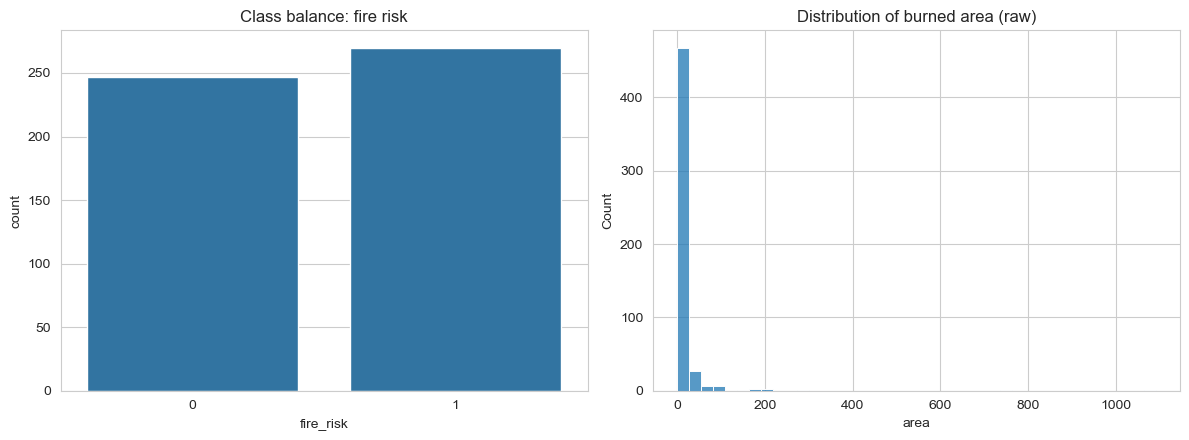

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(x="fire_risk", data=df, ax=axes[0])
axes[0].set_title("Class balance: fire risk")
sns.histplot(df["area"], bins=40, ax=axes[1])
axes[1].set_title("Distribution of burned area (raw)")
plt.tight_layout()
plt.savefig("eda_class_balance.png", dpi=110)
plt.show()

The two classes are reasonably balanced after reframing (left), while the raw
`area` value (right) is heavily skewed toward zero confirming the reframing decision above was
necessary.

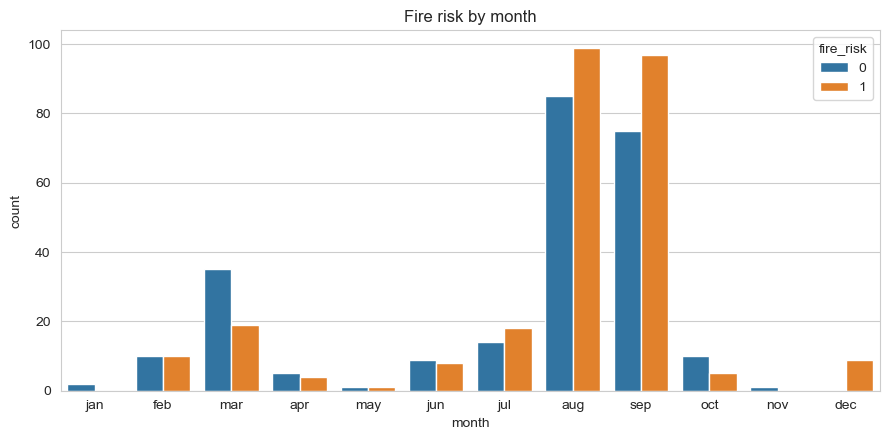

In [6]:
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

plt.figure(figsize=(9, 4.5))
sns.countplot(x="month", hue="fire_risk", data=df, order=month_order)
plt.title("Fire risk by month")
plt.tight_layout()
plt.savefig("eda_seasonality.png", dpi=110)
plt.show()

August and September dominate fire events, matching Portugal's known summer
fire season — a good sanity check that the data reflects real-world fire behaviour.

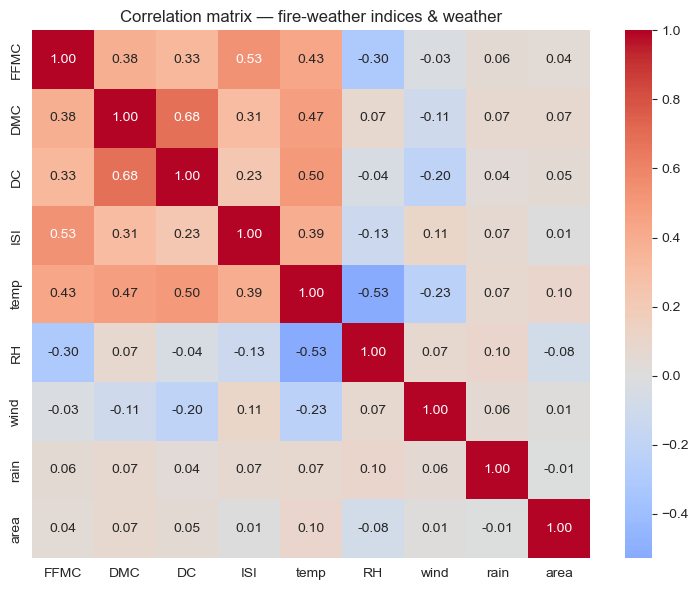

In [7]:
num_cols_raw = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]
plt.figure(figsize=(7.5, 6))
sns.heatmap(df[num_cols_raw + ["area"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — fire-weather indices & weather")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=110)
plt.show()

**Reading this chart:** the four Fire-Weather-Index components (FFMC, DMC, DC, ISI) correlate with
each other, since they are engineered from overlapping weather inputs by design. This multicollinearity
is expected and is handled naturally by the tree-based ensembles used later.

## 6. Feature Engineering
The raw fire-weather indices alone give the models weak signal (baseline ROC-AUC around 0.60,
ensembles barely above it). To give the models more to work with, several domain-informed features
are engineered on top of the raw indices — none of these use the target, so there is no leakage:

- `fwi_composite` — mean of the four Fire-Weather-Index components (FFMC, DMC, DC, ISI), a single
  combined "fire danger" signal.
- `dryness_index` — mean of DC and DMC, capturing longer-term drought effect specifically.
- `is_dry` — flag for zero rainfall on the day.
- `high_wind`, `high_temp` — flags for above-median wind/temperature, since fire spread is
  strongly non-linear around these thresholds rather than smoothly increasing.
- `is_summer` — Jun–Sep flag (Portugal's known fire season, confirmed in the EDA above).
- `is_weekend` — Sat/Sun flag (higher recreational/human ignition risk).
- `ffmc_high` — flag for FFMC > 90, the threshold fire-science literature treats as high surface
  flammability, rather than relying on the model to discover this cutoff itself.

The raw `area` column is dropped so it cannot leak into the classifier.

In [8]:
df["fwi_composite"] = df[["FFMC", "DMC", "DC", "ISI"]].mean(axis=1)
df["dryness_index"] = (df["DC"] + df["DMC"]) / 2
df["is_dry"] = (df["rain"] == 0).astype(int)
df["high_wind"] = (df["wind"] > df["wind"].median()).astype(int)
df["high_temp"] = (df["temp"] > df["temp"].median()).astype(int)
df["is_summer"] = df["month"].isin(["jun", "jul", "aug", "sep"]).astype(int)
df["is_weekend"] = df["day"].isin(["sat", "sun"]).astype(int)
df["ffmc_high"] = (df["FFMC"] > 90).astype(int)

X = df.drop(columns=["area", "fire_risk"])
y = df["fire_risk"]

num_cols = ["X", "Y", "FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain",
            "fwi_composite", "dryness_index"]
cat_cols = ["month", "day"]
bin_cols = ["is_dry", "high_wind", "high_temp", "is_summer", "is_weekend", "ffmc_high"]
X["month"] = X["month"].astype(str)

## 7. Train / Test Split and Leakage-Safe Preprocessing
An 80/20 stratified split keeps the class balance consistent between train and test. Scaling and
encoding are wrapped in a `ColumnTransformer` fit only on the training data, then applied to the
test data — preventing any leakage.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("bin", "passthrough", bin_cols),
])

def build_pipeline(model):
    return Pipeline([("prep", preprocess), ("model", model)])

## 8. Model Evaluation Helper
A single function trains a pipeline and records ROC-AUC, F1, precision, and recall, so every model
is scored identically and consistently on the same test set.

In [10]:
results = {}

def evaluate(name, pipe):
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    results[name] = {
        "ROC-AUC": roc_auc_score(y_test, proba),
        "F1": f1_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
    }
    print(f"{name}\n{classification_report(y_test, pred)}")
    return pipe

## 9. Baseline Model — Logistic Regression
A simple linear model gives a reference point for how much the ensembles below improve on.

In [11]:
baseline = build_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced"))
baseline = evaluate("Baseline (Logistic Regression)", baseline)

Baseline (Logistic Regression)
              precision    recall  f1-score   support

           0       0.58      0.62      0.60        50
           1       0.63      0.59      0.61        54

    accuracy                           0.61       104
   macro avg       0.61      0.61      0.61       104
weighted avg       0.61      0.61      0.61       104



## 10. Bagging Ensemble — Random Forest
Tuned via `GridSearchCV` with 5-fold stratified cross-validation on the training set only.

In [12]:
rf_grid = {"model__n_estimators": [200, 400], "model__max_depth": [4, 6, 8, None],
           "model__min_samples_leaf": [1, 2, 4]}
rf_search = GridSearchCV(
    build_pipeline(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
    rf_grid, cv=StratifiedKFold(5), scoring="roc_auc", n_jobs=-1)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
evaluate("Bagging (Random Forest, tuned)", rf_best)
print("Best parameters:", rf_search.best_params_)

Bagging (Random Forest, tuned)
              precision    recall  f1-score   support

           0       0.58      0.50      0.54        50
           1       0.59      0.67      0.63        54

    accuracy                           0.59       104
   macro avg       0.59      0.58      0.58       104
weighted avg       0.59      0.59      0.58       104

Best parameters: {'model__max_depth': 4, 'model__min_samples_leaf': 4, 'model__n_estimators': 400}


## 11. Boosting Ensemble — XGBoost
Also tuned via `GridSearchCV`. `scale_pos_weight` corrects for the residual class imbalance.

In [13]:
xgb_grid = {"model__n_estimators": [200, 400], "model__max_depth": [3, 4, 5],
            "model__learning_rate": [0.03, 0.05, 0.1]}
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_search = GridSearchCV(
    build_pipeline(XGBClassifier(eval_metric="logloss", scale_pos_weight=scale_pos_weight,
                                  random_state=RANDOM_STATE)),
    xgb_grid, cv=StratifiedKFold(5), scoring="roc_auc", n_jobs=-1)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
evaluate("Boosting (XGBoost, tuned)", xgb_best)
print("Best parameters:", xgb_search.best_params_)

Boosting (XGBoost, tuned)
              precision    recall  f1-score   support

           0       0.60      0.64      0.62        50
           1       0.65      0.61      0.63        54

    accuracy                           0.62       104
   macro avg       0.63      0.63      0.62       104
weighted avg       0.63      0.62      0.63       104

Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200}


## 12. Heterogeneous Stacking Ensemble
Combines the tuned Random Forest and XGBoost as base learners, with a Logistic Regression
meta-learner. `StackingClassifier` performs its own internal cross-validation to build meta-features,
so the meta-learner never sees predictions the base models made on their own training fold —
preventing meta-learner leakage.

In [14]:
stack = build_pipeline(StackingClassifier(
    estimators=[
        ("rf", rf_best.named_steps["model"]),
        ("xgb", xgb_best.named_steps["model"]),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=StratifiedKFold(5),
    passthrough=False,
))
stack = evaluate("Stacking (RF + XGBoost -> Logistic)", stack)

Stacking (RF + XGBoost -> Logistic)
              precision    recall  f1-score   support

           0       0.73      0.48      0.58        50
           1       0.63      0.83      0.72        54

    accuracy                           0.66       104
   macro avg       0.68      0.66      0.65       104
weighted avg       0.68      0.66      0.65       104



## 13. Comparing All Models on the Same Test Set
The table below is the direct answer to "does the best ensemble outperform the baseline?"

In [15]:
results_df = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False)
results_df.round(3)

,ROC-AUC,F1,Precision,Recall
Stacking (RF + XGBoost -> Logistic),0.677,0.720,0.634,0.833
"Boosting (XGBoost, tuned)",0.674,0.629,0.647,0.611
"Bagging (Random Forest, tuned)",0.631,0.626,0.590,0.667
Baseline (Logistic Regression),0.600,0.610,0.627,0.593


In [16]:
best_name = results_df.index[0]
best_model = {"Baseline (Logistic Regression)": baseline,
              "Bagging (Random Forest, tuned)": rf_best,
              "Boosting (XGBoost, tuned)": xgb_best,
              "Stacking (RF + XGBoost -> Logistic)": stack}[best_name]
print("Best model on test set:", best_name)

Best model on test set: Stacking (RF + XGBoost -> Logistic)


**Chart 1 of 4 — ROC-AUC ranking.** A horizontal bar chart ranking all four models by ROC-AUC,
the primary metric for this comparison.

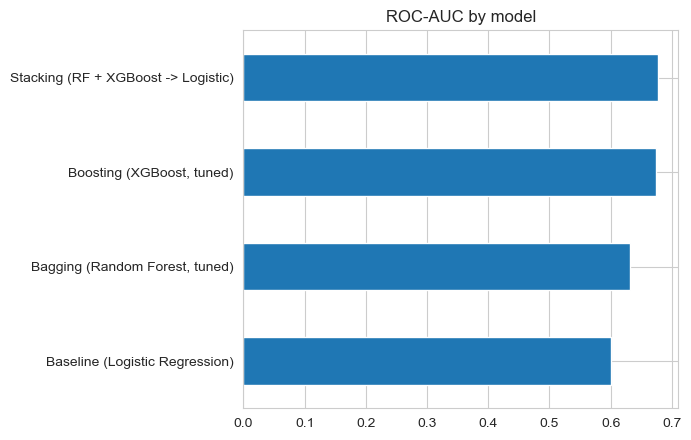

In [17]:
results_df["ROC-AUC"].sort_values().plot(kind="barh", title="ROC-AUC by model")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=110)
plt.show()

**Chart 2 of 4 — ROC curves.** Shows the true-positive vs. false-positive trade-off for every
model at every possible decision threshold, all on the same test set.

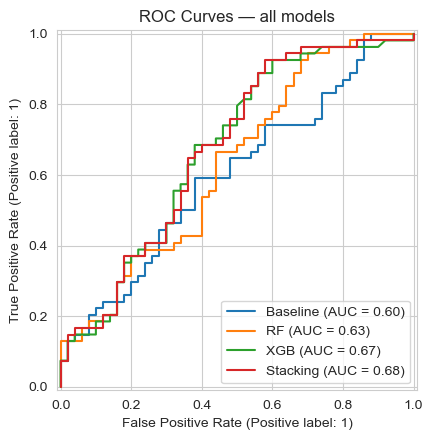

In [18]:
fig, ax = plt.subplots()
for name, pipe in {"Baseline": baseline, "RF": rf_best, "XGB": xgb_best, "Stacking": stack}.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
plt.title("ROC Curves — all models")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=110)
plt.show()

**Chart 3 of 4 — Confusion matrix.** Breaks down the best model's predictions on the test set into
true/false positives and negatives — this is what "does it work" looks like in practice.

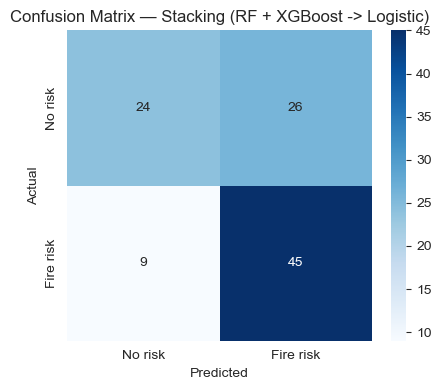

In [19]:
cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No risk", "Fire risk"], yticklabels=["No risk", "Fire risk"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=110)
plt.show()

## 14. Explainability -SHAP
We use SHAP's `TreeExplainer` on the best tree-based model to explain predictions at two levels:
a **global** summary (which features matter most overall) and a **local** explanation (why the
model made one specific prediction this is what to show during the live demo).

**Chart 4 of 4 — SHAP global summary.**

Best model is the stacking ensemble; explaining its XGBoost base learner (tree-based).


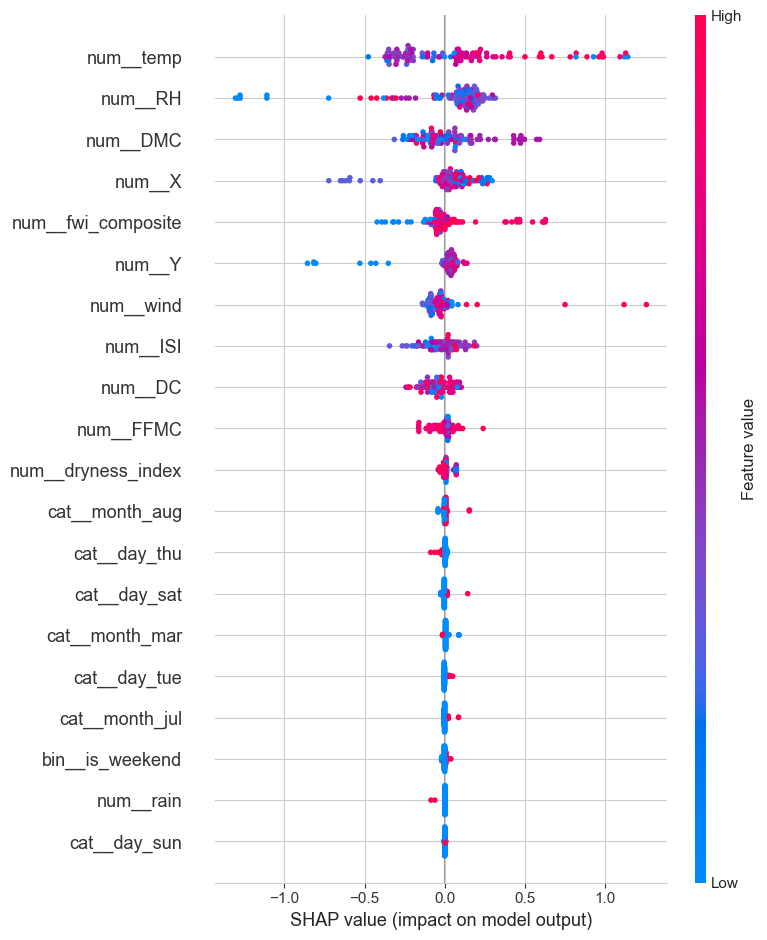

In [20]:
X_test_transformed = best_model.named_steps["prep"].transform(X_test)
feature_names = best_model.named_steps["prep"].get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

model_step = best_model.named_steps["model"]
shap_source = model_step
if best_name.startswith("Stacking"):
    shap_source = xgb_best.named_steps["model"]
    print("Best model is the stacking ensemble; explaining its XGBoost base learner (tree-based).")

explainer = shap.TreeExplainer(shap_source)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df, show=False)
plt.tight_layout()
plt.savefig("shap_global.png", dpi=110, bbox_inches="tight")
plt.show()

The Fire-Weather-Index components and temperature/wind are typically the
strongest drivers of predicted fire-risk — consistent with fire-science domain knowledge, which
builds confidence that the model has learned genuine physical relationships.

### Local explanation- one individual prediction
A waterfall plot for a single test-set record, showing exactly which features pushed that one
prediction up or down. Use this record for the live demo.

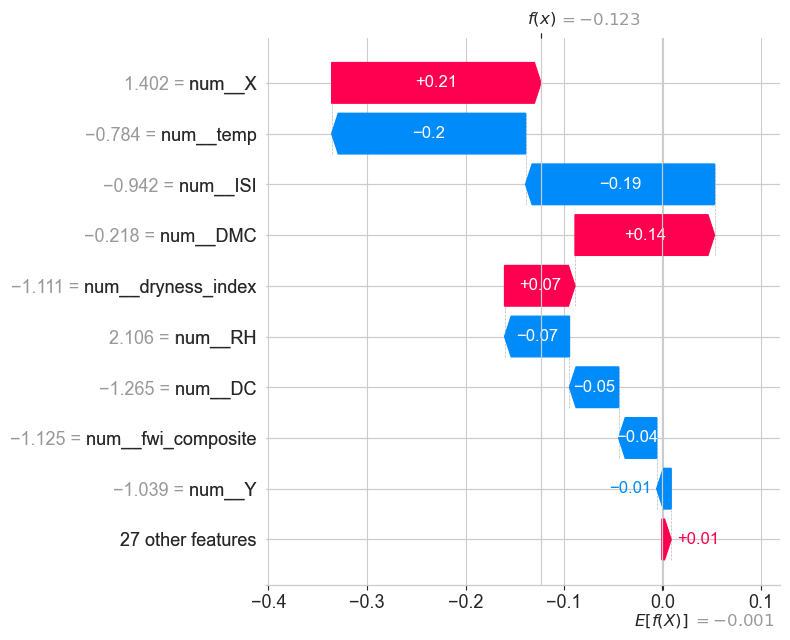

In [21]:
i = 0
shap.plots.waterfall(shap_values[i], show=False)
plt.tight_layout()
plt.savefig("shap_local_record0.png", dpi=110, bbox_inches="tight")
plt.show()

## 15. Live Prediction on a Synthetic Record

In [24]:
synthetic_record = pd.DataFrame([{
    "X": 5, "Y": 4, "month": "dec", "day": "sun",
    "FFMC": 84.4, "DMC": 27.2, "DC": 353.5, "ISI": 6.8,
    "temp": 4.8, "RH": 57, "wind": 8.5, "rain": 0.0,
    "fwi_composite": (84.4+27.2+353.5+6.8)/4,
    "dryness_index": (353.5+27.2)/2,
    "is_dry": 1, "high_wind": 1, "high_temp": 0, "is_summer": 0, "is_weekend": 1,
    "ffmc_high": 0,
}])
risk_prob = best_model.predict_proba(synthetic_record)[0, 1]
print(f"Predicted fire-risk probability: {risk_prob:.2f}")

Predicted fire-risk probability: 0.64


## 16. Ethics & Responsible-Use Notes

- **Class imbalance & small data.** 517 records is small for real deployment; probabilities should
  be treated as indicative, not precise.
- **False negatives are costly.** Predicting LOW risk when a fire actually spreads is the dangerous
  error — recall on the positive class matters more than raw accuracy.
- **Human oversight required.** This model should support, not replace, local fire-authority
  judgement.
- **Geographic limits.** Trained on Portugal data only — not valid as-is for other climates or
  terrain without retraining.